# Linear Autoencoder

This is the most basic version possible.
Fully connected layers with no nonlinearities, and treats each 28x28 image as a flat 784-dimensional vector.

So, this is the baseline.
Every future version should beat this.
The main question we'll explore here is this: how much info can a linear transformation preserve at different compression ratios? 

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from training.dataloader import get_dataloaders, DATASET_INFO, get_input_dim
from models.v1_linear_ae import LinearAutoencoder

In [2]:
def load_v1(dataset, latent_dim=32):
    info = DATASET_INFO[dataset]
    input_dim = get_input_dim(dataset)
    model = LinearAutoencoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        channels=info['channels'],
        height=info['height'],
        width=info['width'],
    )
    ckpt = f'../checkpoints/v1_linear_ae/{dataset}_ld{latent_dim}.pt'
    model.load_state_dict(torch.load(ckpt, map_location='cpu'))
    model.eval()
    return model

## MNIST Results

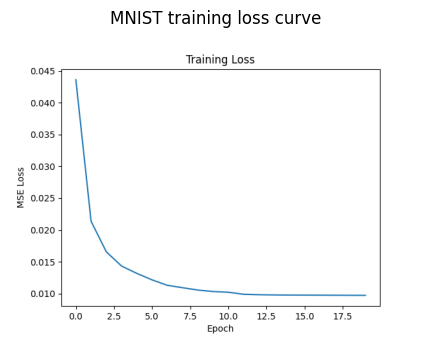

In [3]:
img = mpimg.imread('../results/v1_linear_ae/mnist_ld32_loss_curve.png')
plt.figure(figsize=(7, 4))
plt.imshow(img)
plt.axis('off')
plt.title('MNIST training loss curve')
plt.show()

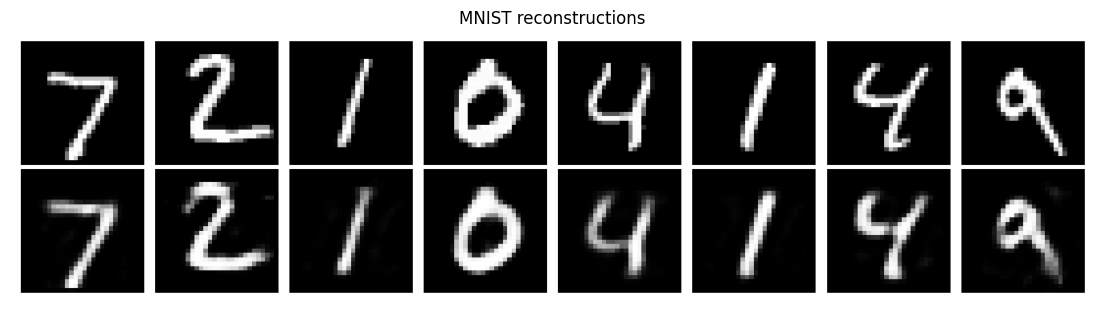

In [4]:
img = mpimg.imread('../results/v1_linear_ae/mnist_ld32_reconstructions.png')
plt.figure(figsize=(14, 4))
plt.imshow(img)
plt.axis('off')
plt.title('MNIST reconstructions')
plt.show()

In [5]:
_, test_loader = get_dataloaders(dataset='mnist', data_dir='../data', batch_size=128)
model_mnist = load_v1('mnist', latent_dim=32)

all_latents = []
all_labels = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        _, latents = model_mnist(imgs)
        all_latents.append(latents)
        all_labels.append(lbls)

all_latents = torch.cat(all_latents, dim=0)
all_labels = torch.cat(all_labels, dim=0)

print("Latent shape:", all_latents.shape)
print("Latent mean: ", round(all_latents.mean().item(), 4))
print("Latent std:  ", round(all_latents.std().item(), 4))
print("Latent min:  ", round(all_latents.min().item(), 4))
print("Latent max:  ", round(all_latents.max().item(), 4))

Latent shape: torch.Size([10000, 32])
Latent mean:  0.1361
Latent std:   2.0671
Latent min:   -9.599
Latent max:   9.0146


The latent vectors are unbounded, they can take any real value with no 
constraints on their distribution. This is a fundamental property of a 
plain autoencoder. We'll compare this to the VAE later, where the latent space 
is explicitly regularised to follow a normal distribution. That constraint 
is what makes the VAE's latent space smooth and sampleable.

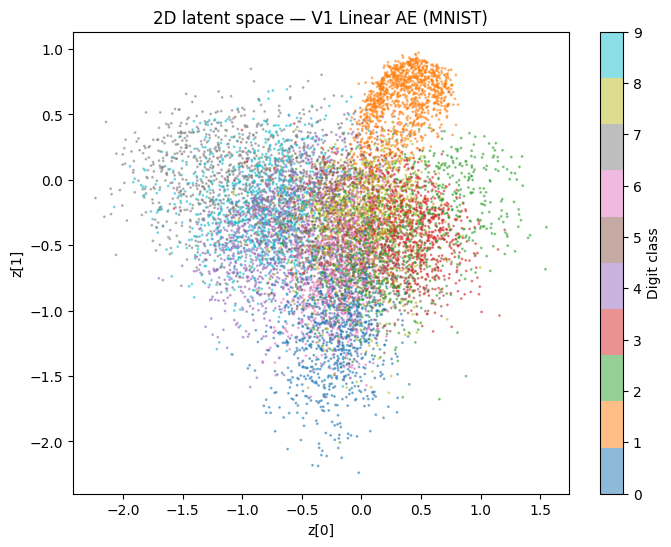

In [8]:
model_2d = load_v1('mnist', latent_dim=2)

latents_2d = []
labels_2d = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        _, z = model_2d(imgs)
        latents_2d.append(z)
        labels_2d.append(lbls)

latents_2d = torch.cat(latents_2d, dim=0).numpy()
labels_2d = torch.cat(labels_2d, dim=0).numpy()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels_2d, cmap='tab10', s=1, alpha=0.5)
plt.colorbar(scatter, label='Digit class')
plt.title('2D latent space — V1 Linear AE (MNIST)')
plt.xlabel('z[0]')
plt.ylabel('z[1]')
plt.show()

## Latent Space Observation

The 2D latent space shows partial separation. Digit 1 is clearly isolated in the top right, since it's a pretty distinct number as a simple vertical stroke. Most other digits overlap heavily in the center.

This is expected behavior for a plain autoencoder. The model only optimizes for reconstruction quality. It has no incentive to organize the latent space. Any 
structure that emerges is incidental.

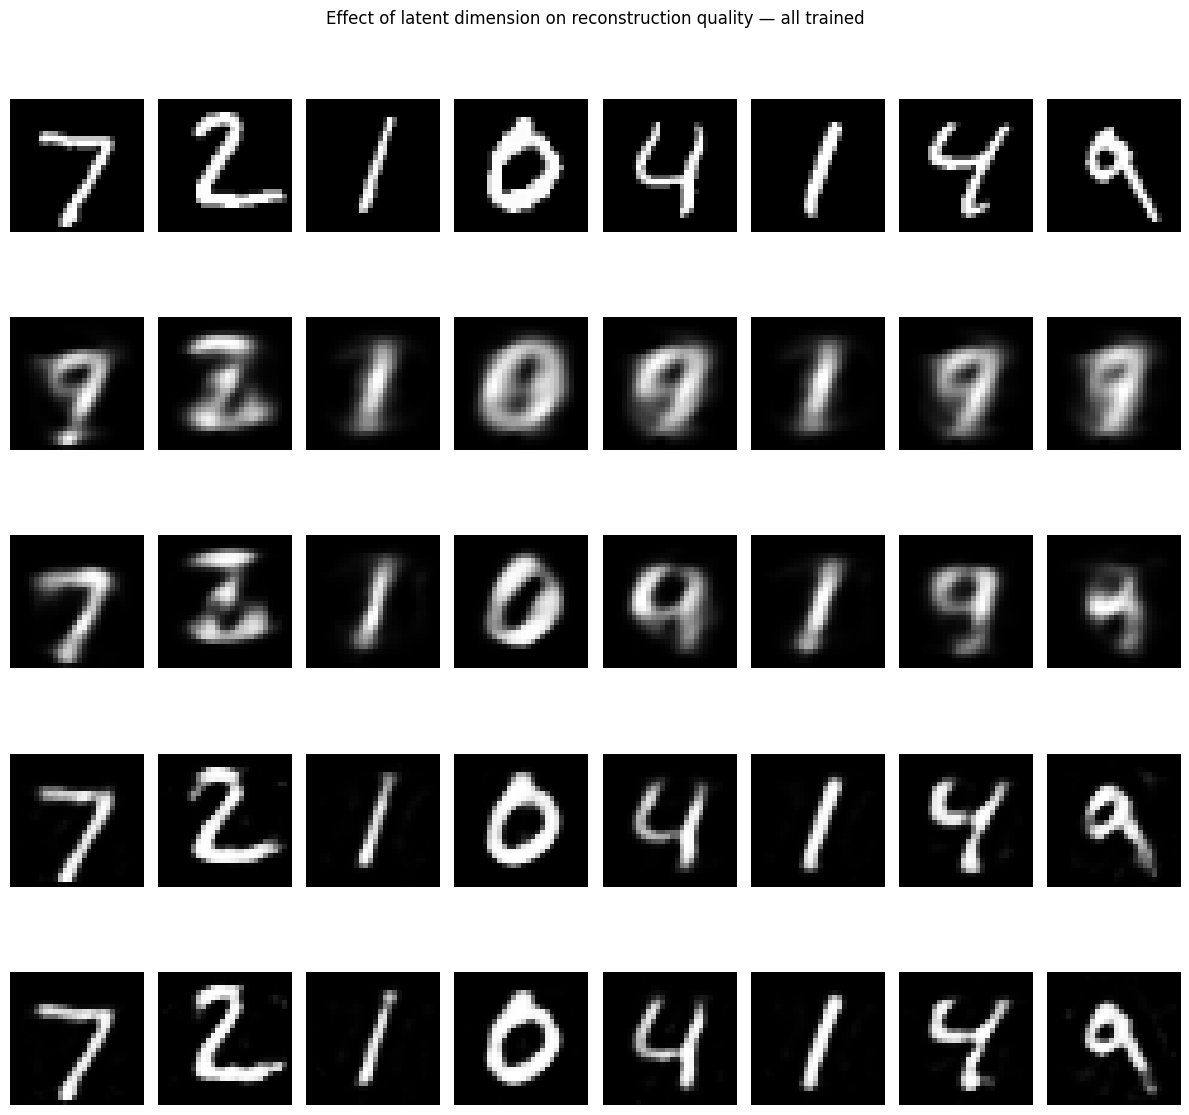

In [10]:
latent_dims = [2, 8, 32, 64]
_, test_loader = get_dataloaders(dataset='mnist', data_dir='../data', batch_size=128)
images, _ = next(iter(test_loader))
sample = images[:8]

fig, axes = plt.subplots(len(latent_dims) + 1, 8, figsize=(12, 12))

axes[0, 0].set_ylabel('Original', fontsize=8)
for i in range(8):
    axes[0, i].imshow(sample[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')

for row, ld in enumerate(latent_dims):
    m = load_v1('mnist', latent_dim=ld)
    ratio = 784 / ld

    with torch.no_grad():
        recons, _ = m(sample)

    axes[row + 1, 0].set_ylabel(f'ld={ld}\n({ratio:.0f}:1)', fontsize=7)
    for i in range(8):
        axes[row + 1, i].imshow(recons[i].squeeze(), cmap='gray')
        axes[row + 1, i].axis('off')

plt.suptitle('Effect of latent dimension on reconstruction quality — all trained')
plt.tight_layout()
plt.show()

## CIFAR-10 Results

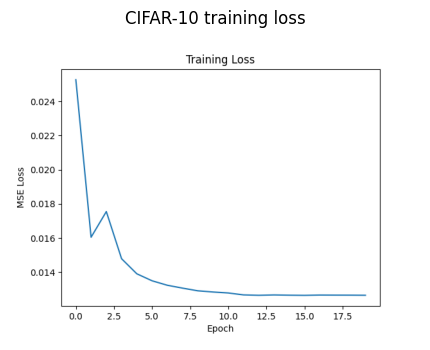

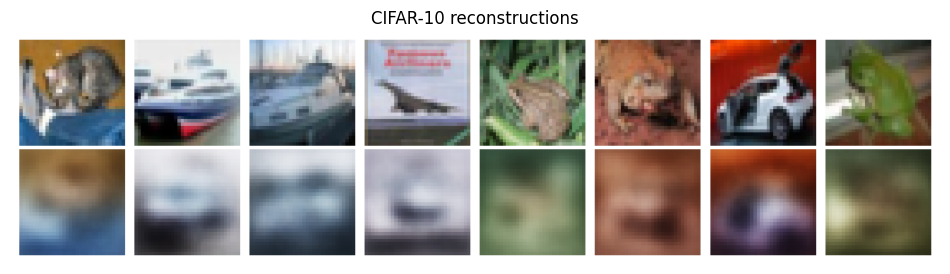

In [11]:
for fname, title in [
    ('../results/v1_linear_ae/cifar10_ld32_loss_curve.png', 'CIFAR-10 training loss'),
    ('../results/v1_linear_ae/cifar10_ld32_reconstructions.png', 'CIFAR-10 reconstructions'),
]:
    img = mpimg.imread(fname)
    plt.figure(figsize=(12, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title)
    plt.show()

## V1 Summary

- Linear autoencoder is mathematically equivalent to PCA
- Reconstruction quality is surprisingly good on MNIST given the simplicity
- latent_dim=32 hits a reasonable quality/compression tradeoff for MNIST
- Latent space has no imposed structure, the partial class separation here emerges incidentally
- CIFAR-10 performance is noticeably worse since linear transformations can't capture the complexity of natural color images